# Compressions, Scaling Patterns, and Multi-Index Design

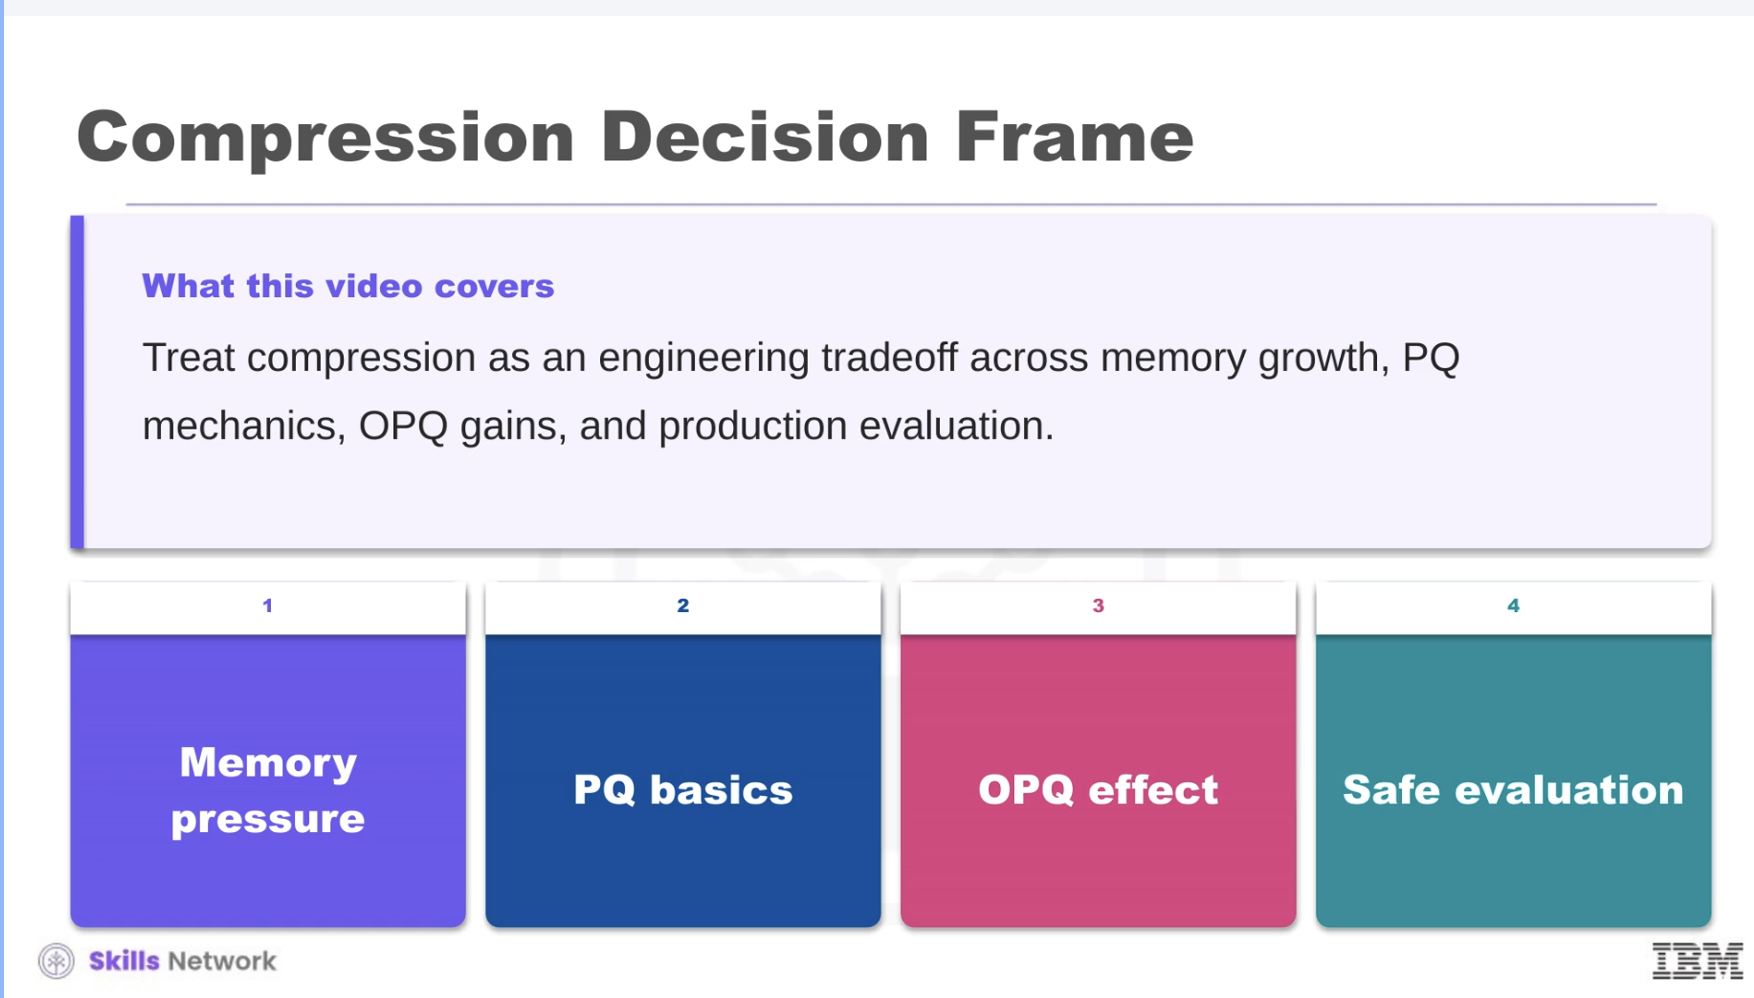
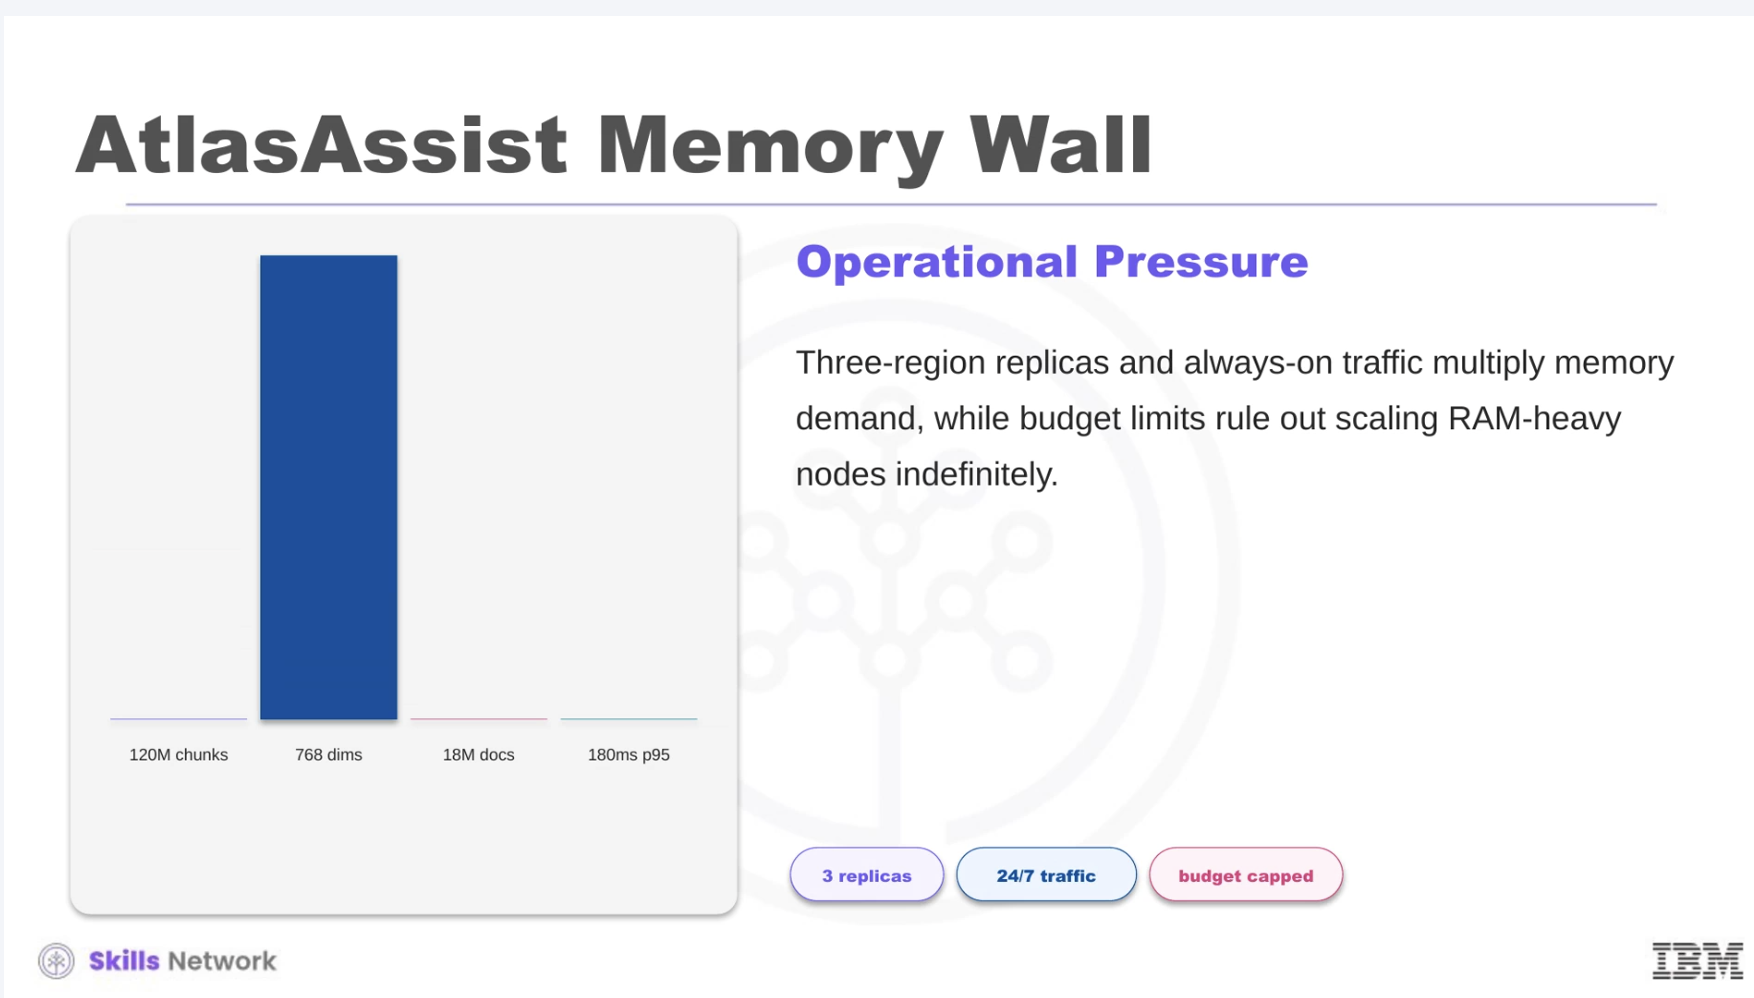
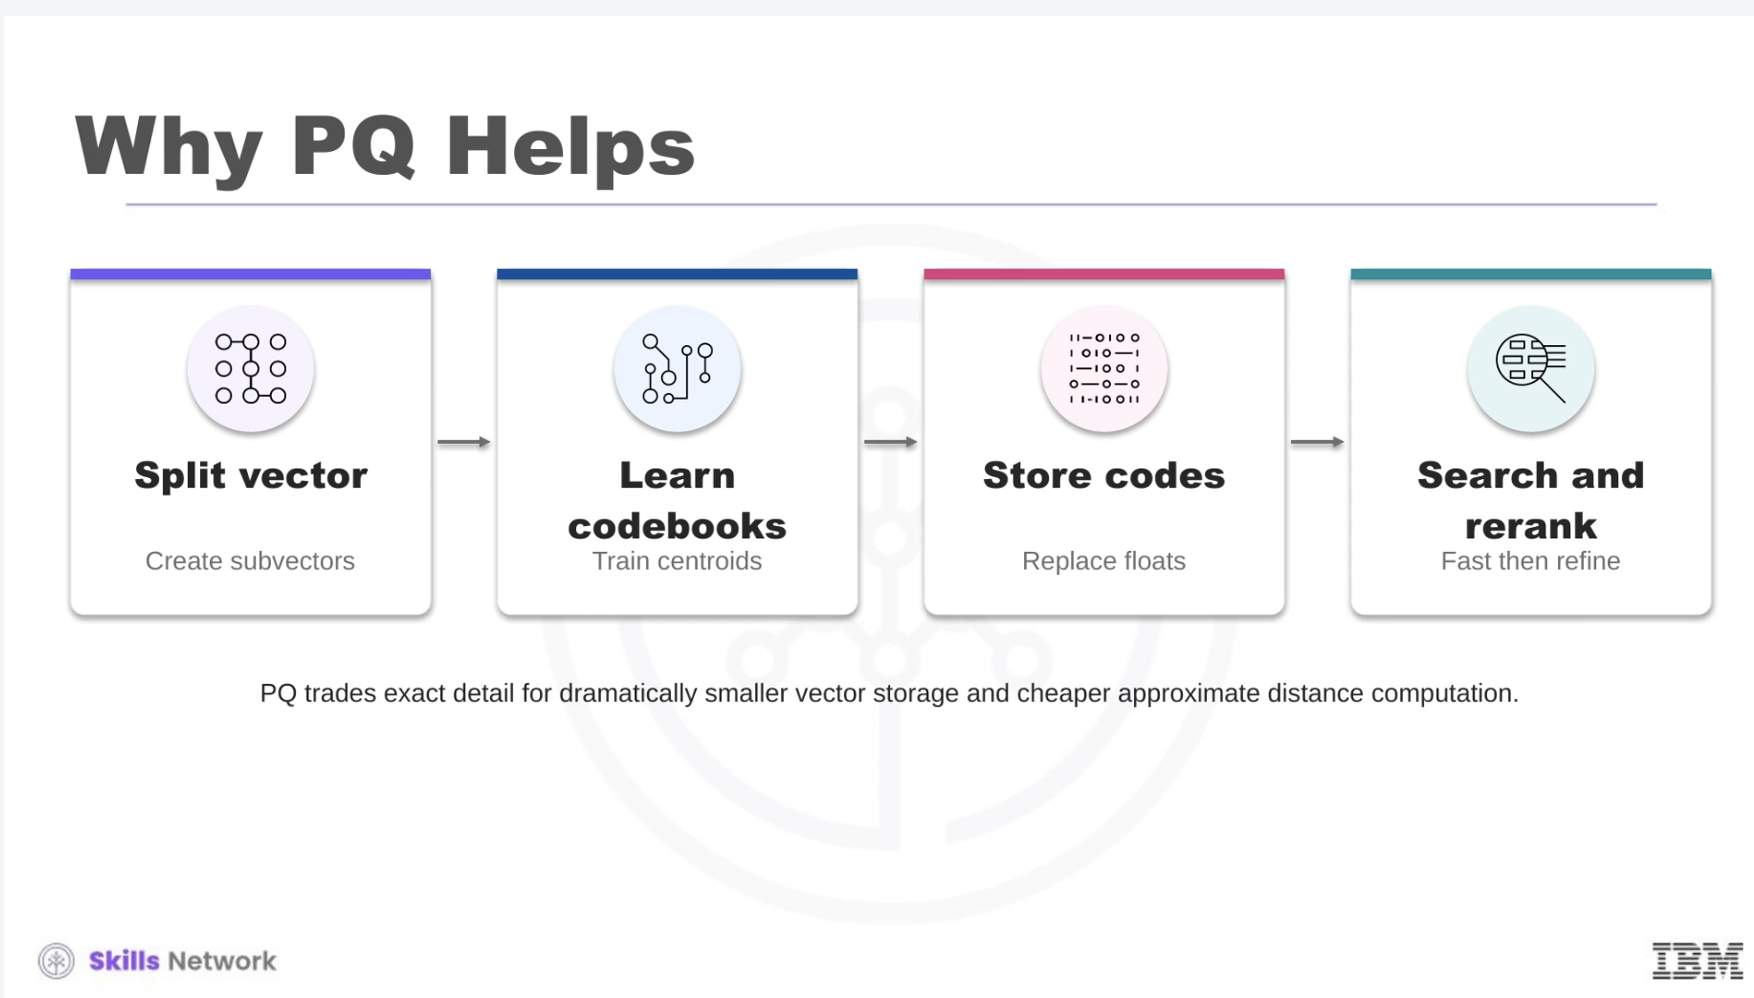
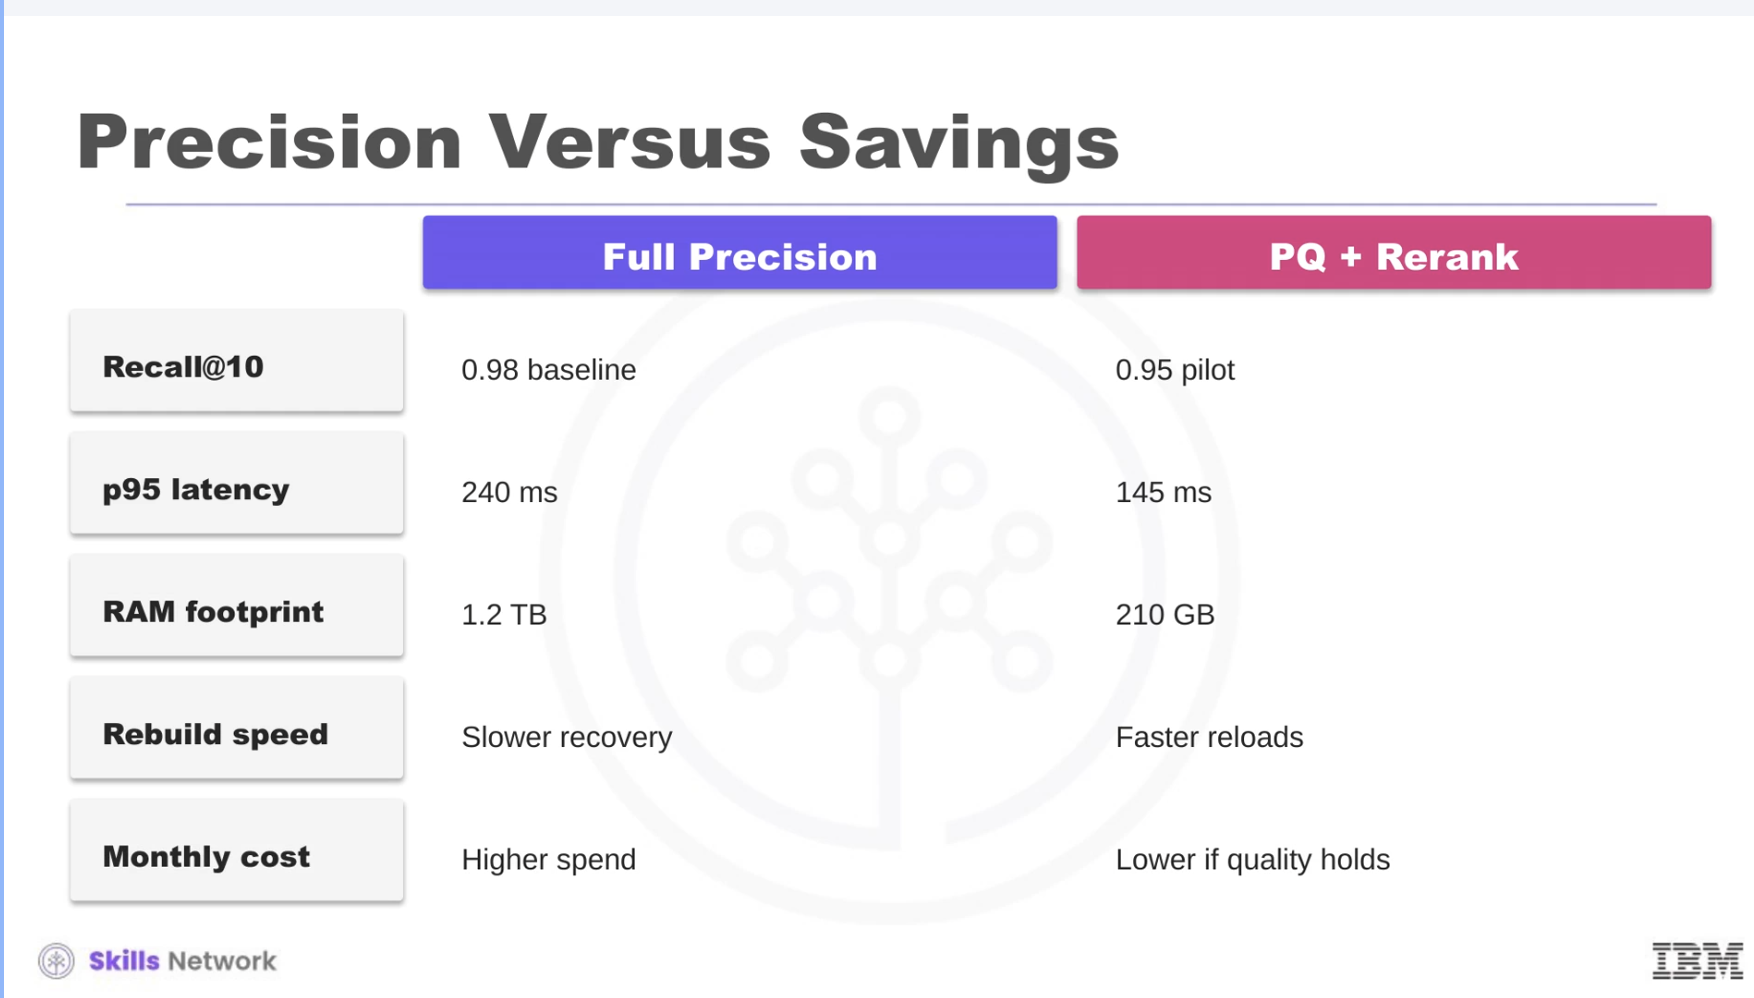
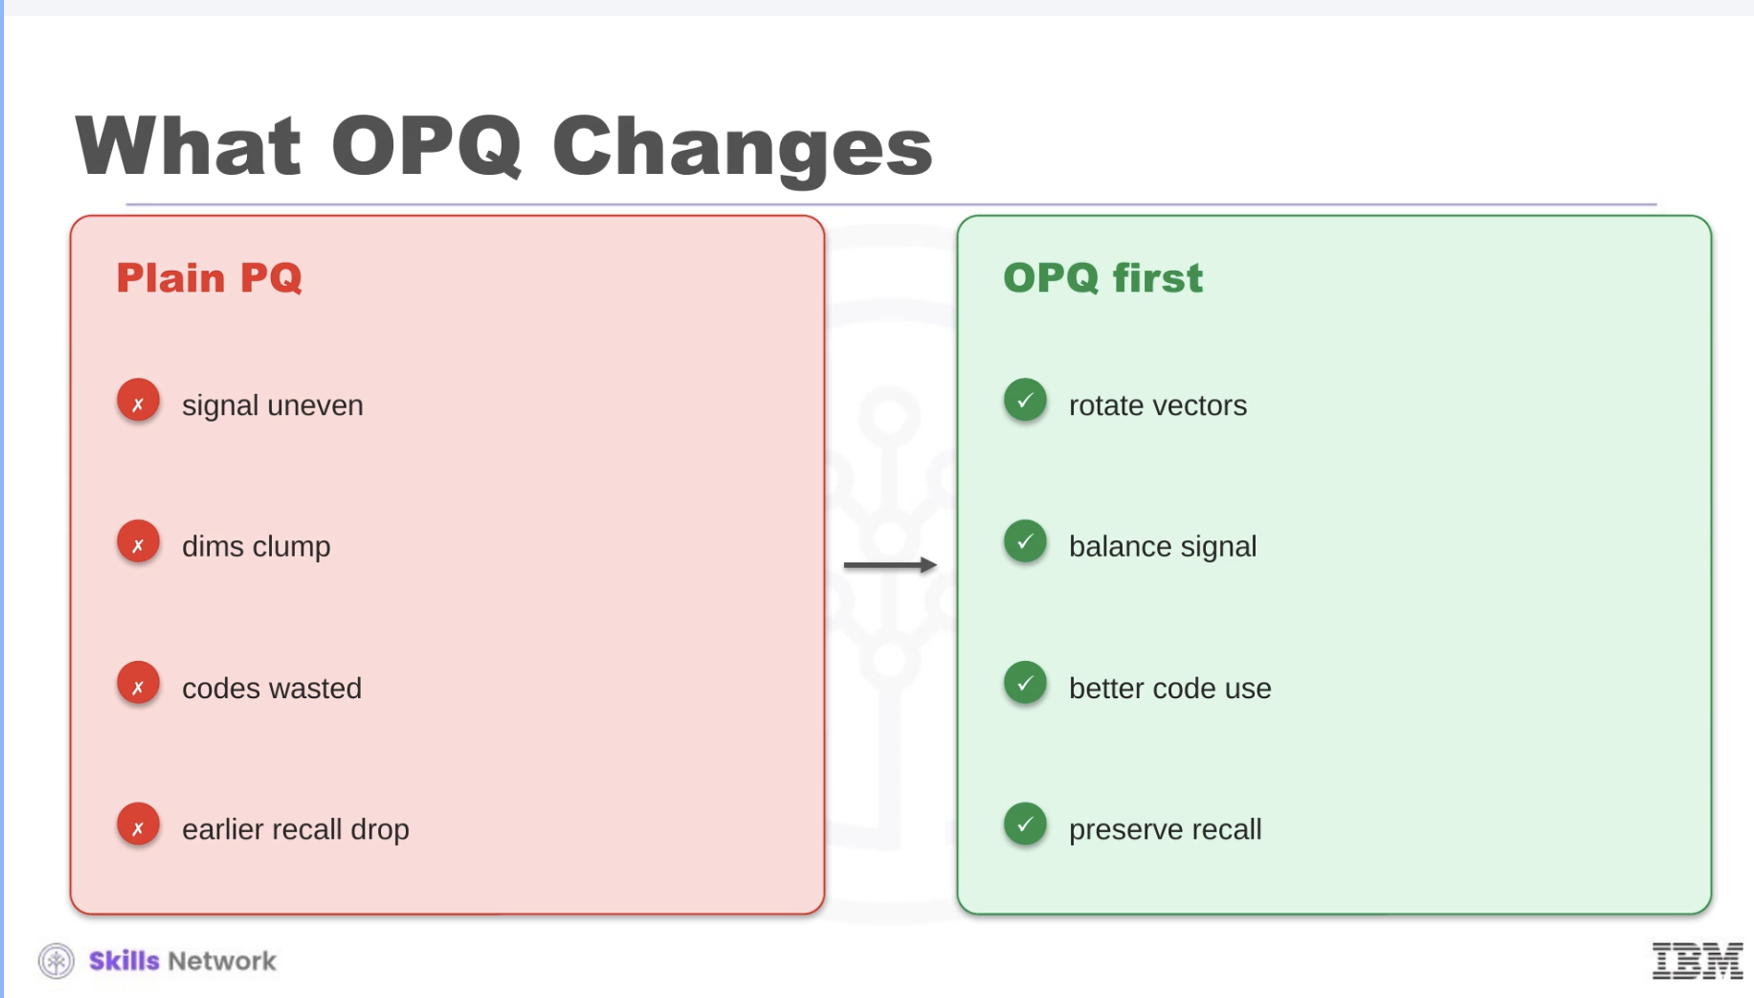
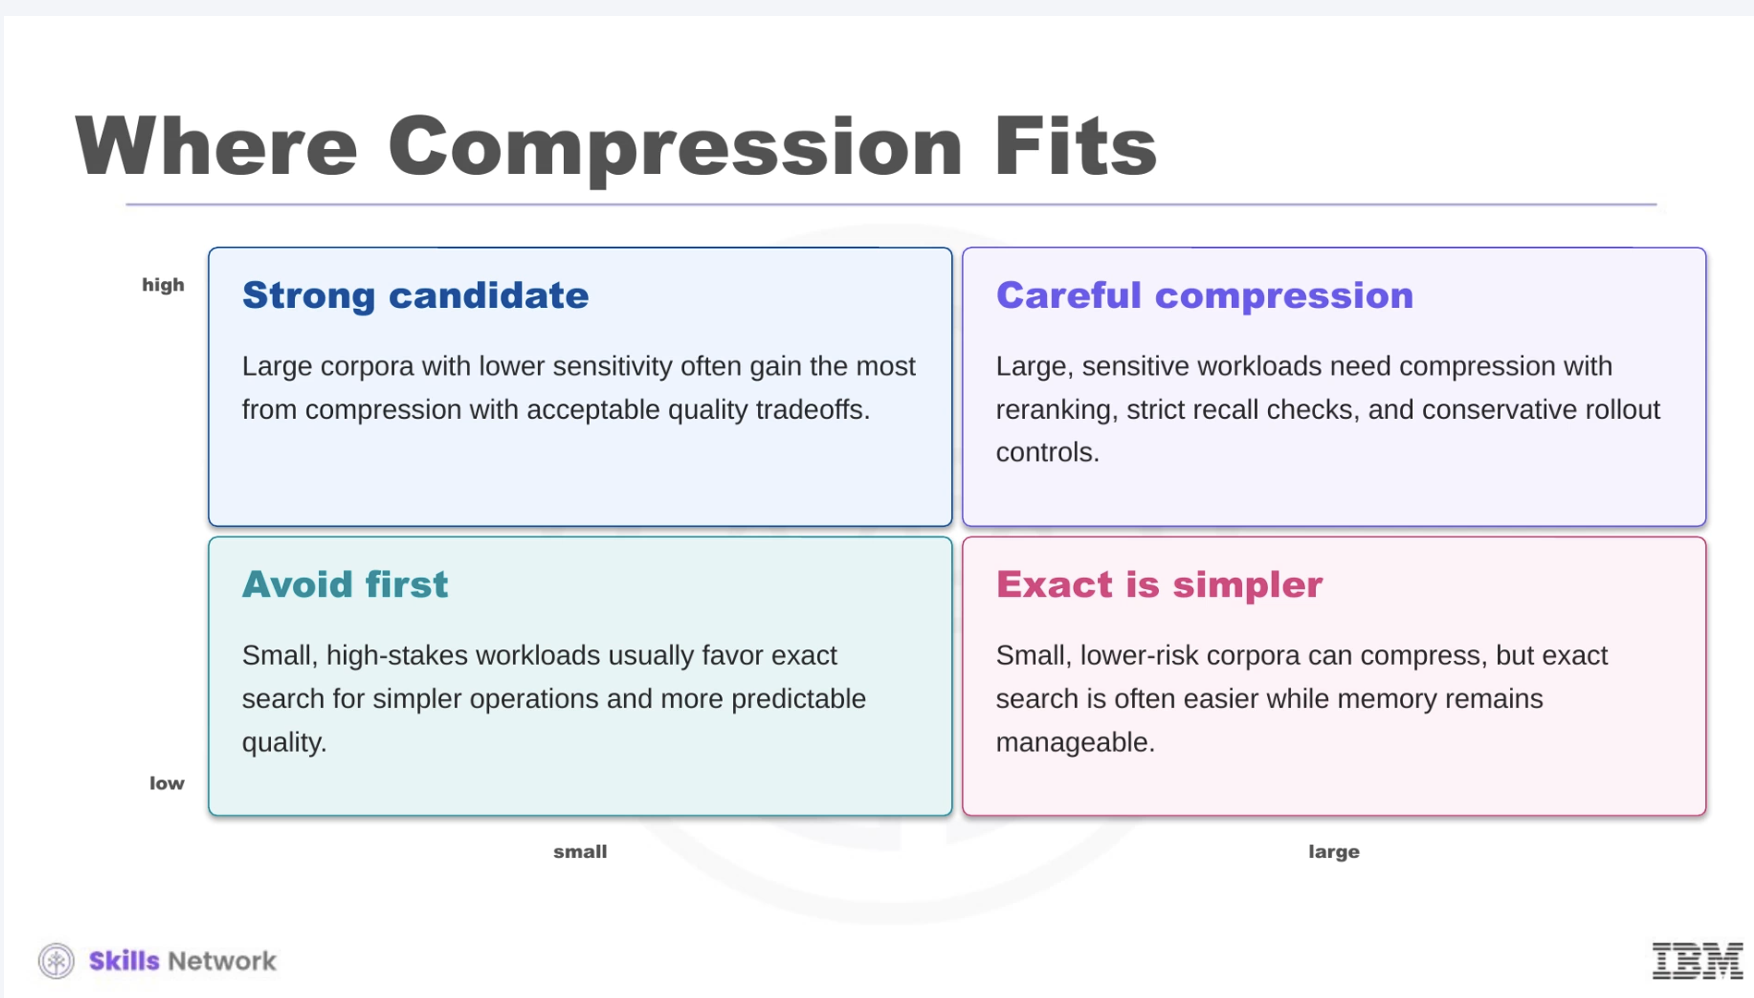
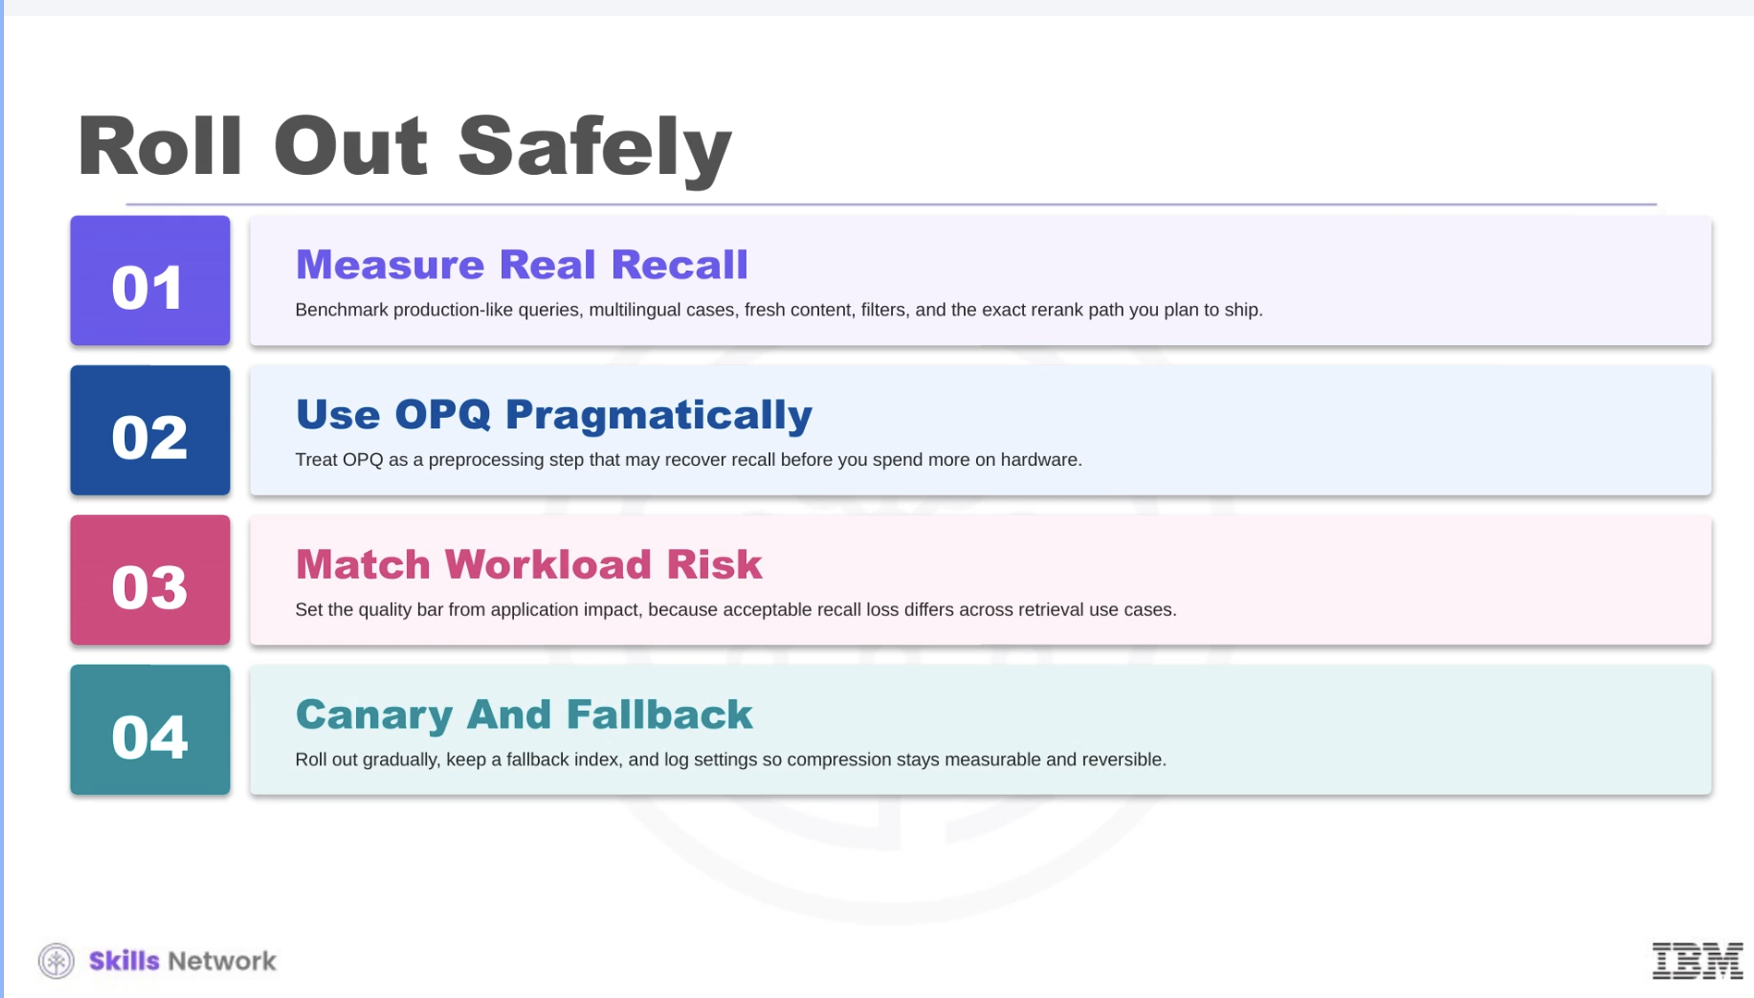



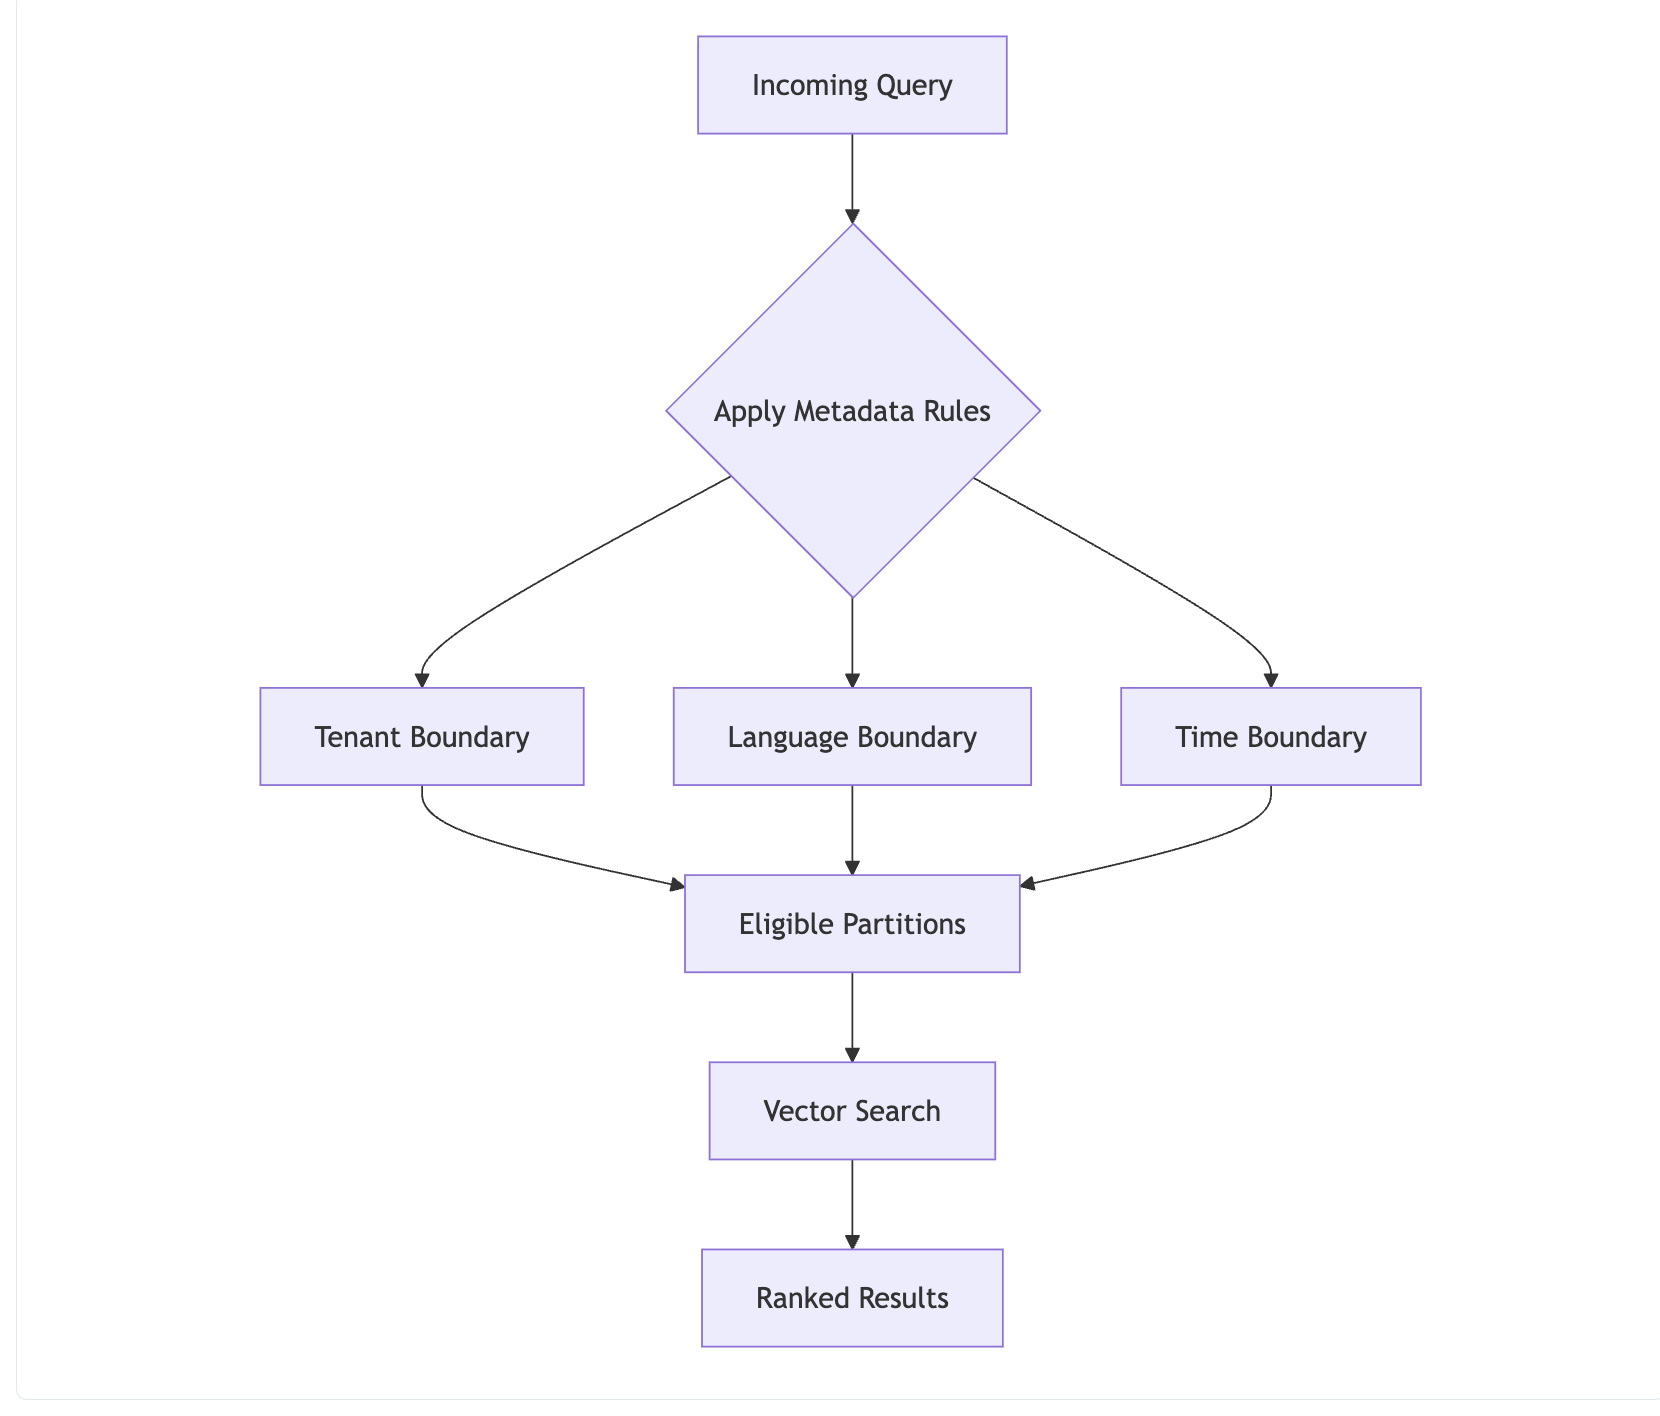

# Sharding, Partitioning & Multi-Index — What I Actually Need to Know

> 💡 **Partitioning defines what may be searched. Routing decides where the query goes. Index design determines how efficiently retrieval happens within the allowed set.**

---

## 1. Sharding — what do I actually need to know?

### The basic idea

Suppose I have:

```
10 million vectors
```

One machine might not be enough. So I split them:

```
                 Vector Database
                       |
          ┌────────────┼────────────┐
          ↓            ↓            ↓
       Shard 1      Shard 2      Shard 3
       3.3M         3.3M         3.4M
```

That's **sharding**.

The important part isn't the mechanics of physically splitting the database. It's this:

> 📌 **Sharding determines where my data lives, and therefore affects capacity, throughput, isolation, and failure behavior.**

### Why should I care?

Because my secure RAG architecture may eventually have things like:

```
Tenant A
Tenant B
Tenant C
```

or:

```
India region
US region
EU region
```

I might deliberately keep them separated. For example:

```
Tenant A → Shard A
Tenant B → Shard B
Tenant C → Shard C
```

Now a Tenant A query doesn't even need to search Tenant B's data.

> 💡 That's both a **scaling decision** and a **security/isolation decision**.

---

## 2. The important problem with sharding

Suppose documents are split randomly:

```
Shard 1 → documents 1, 5, 9...
Shard 2 → documents 2, 6, 10...
Shard 3 → documents 3, 7, 11...
```

User asks:

```
"What is our refund policy?"
```

The router doesn't know which shard contains the best answer. So it might have to do:

```
                Query
                  ↓
             Query Router
            /      |      \
           ↓       ↓       ↓
        Shard 1  Shard 2  Shard 3
           ↓       ↓       ↓
        results  results  results
            \      |      /
             ↓     ↓     ↓
             Merge top-k
                  ↓
             Final results
```

That's **distributed retrieval**. The system now has to search multiple shards and merge their candidates into one ranked result list.

What I need to remember:

> 📌 **Sharding introduces routing + cross-shard merging.**
> That's the important bit.

---

## 3. Partitioning — THIS is more important for my security RAG

Here's where the course makes a very important distinction:

> 💡 **Sharding spreads the load. Partitioning narrows what is eligible to be searched.**

Think:

| | Asks |
|---|---|
| **Sharding** | *Where is the data stored?* |
| **Partitioning** | *Which data is allowed to participate in this query?* |

This is highly relevant to my security architecture.

### Example

Imagine the vector database contains:

```
Tenant A
Tenant B

English
Hindi

Public
Restricted

2026 documents
2025 documents
2024 documents
```

User's permissions:

```
Tenant A
English
Last 90 days
```

### ❌ I don't want to:

```
Search EVERYTHING
       ↓
Get top 100
       ↓
Remove unauthorized documents
```

### ✅ Instead:

```
User Query
    ↓
Metadata / permission rules
    ↓
Eligible partitions
    ↓
Vector search
    ↓
Results
```

> 📌 The source specifically emphasizes that **sensitive access boundaries should be enforced before or during routing**, rather than relying on relevance ranking and filtering afterward.

This directly connects to the security concepts I've already learned.

---

## 4. Sharding vs Partitioning

This distinction is worth memorizing:

| | Sharding | Partitioning |
|---|---|---|
| Main purpose | Distribute data/load | Restrict search scope |
| Main question | "Where does it live?" | "What is eligible?" |
| Helps scale? | Yes | Can |
| Helps isolation? | Yes | Yes |
| Security relevance | High | **Very high** |

Don't overcomplicate this.

---

## 5. Multi-index strategies

Sometimes one giant vector index isn't suitable for everything.

I might have separate indexes for:

```
Product documents
Legal documents
Support documents
```

Or:

```
Text embeddings
Image embeddings
Audio embeddings
```

Or:

```
Hot data
Warm data
Archive
```

The course lists these as common multi-index patterns.

### Why would I do this?

Because different data can have different:

- workloads
- update frequencies
- access requirements
- embedding models
- latency requirements
- isolation requirements

For example:

```
Hot index
↓
frequently updated data

Archive index
↓
rarely updated historical data
```

I don't necessarily want to manage both using exactly the same retrieval strategy.

---

## 6. ⚠️ But there's a catch

Every additional index gives me another thing to maintain.

Suppose I have:

```
Index A
Index B
Index C
Index D
Index E
```

Now I have to make sure:

```
updates      → all indexes
deletes      → all indexes
permissions  → all indexes
metadata     → consistent
embeddings   → consistent
monitoring   → all indexes
```

Otherwise I can get:

### Duplicated vectors

Same document exists in multiple indexes. One gets updated. The other doesn't. Now:

```
Index A → new document
Index B → old document
```

### Stale indexes

Source changes but one index isn't refreshed.

### Inconsistent filters

Same user/query somehow gets different permitted results depending on which route they hit.

> 📌 The course specifically identifies **hot shards, uneven partitions, duplicated vectors, stale indexes, and inconsistent metadata filters** as production risks.

---

## 7. 🧠 The architecture mental model to keep

This is probably the most important part of the entire section:

```
                 USER QUERY
                     ↓
              ┌──────────────┐
              │  ELIGIBILITY │
              │   / POLICY   │
              └──────┬───────┘
                     ↓
             Which data may I search?
                     ↓
              ┌──────────────┐
              │    ROUTER    │
              └──────┬───────┘
                     ↓
              Where should I search?
                     ↓
          ┌──────────┼──────────┐
          ↓          ↓          ↓
       Index 1    Index 2    Index 3
          ↓          ↓          ↓
          └──────────┼──────────┘
                     ↓
                  MERGE
                     ↓
                RANKED TOP-K
```

And inside each index:

```
Index
  ↓
ANN algorithm
  ↓
Efficient vector search
```

So the course's final conceptual separation is:

| Layer | Role |
|---|---|
| **Partitioning** | Defines **what** may be searched |
| **Routing** | Decides **where** the query goes |
| **Index design** | Determines **how efficiently** retrieval happens within the allowed set |

---

## 8. What I should actually retain

Forget the 200-line implementation details.

### 🔴 Must know

| Term | Meaning |
|---|---|
| **Sharding** | Splitting vectors across multiple infrastructure/index instances for scale, isolation, and workload distribution. |
| **Partitioning** | Restricting the set of records eligible for a query based on metadata/governance boundaries. |
| **Routing** | Deciding which shard/index/partition receives the query. |
| **Multi-index** | Using separate indexes when different datasets/workloads have meaningfully different requirements. |
| **Cross-shard merge** | Search multiple shards → collect candidates → merge/rank them into final top-k. |
| **Security** | Permission boundaries should influence eligibility/routing before or during retrieval, not be treated as an afterthought after ranking. |

### 🟡 Conceptually understand

- Hot shards
- Stale indexes
- Duplicate vectors
- Uneven partitions
- Inconsistent filters
- Freshness-tier indexes
- Tenant/domain/model-specific indexes

### 🟢 Don't stress about

- The exact implementation of sharding.
- How a particular vector DB physically stores shards.
- Memorizing every partitioning pattern.
- Writing the router myself.

---

## 9. The connection to MY RAG project

This section actually matters more to my project than the previous NumPy stuff.

I was already thinking about:

```
User
 ↓
Main LLM
 ↓
Retrieval
 ↓
Security / policy checking
 ↓
Response
```

Now I'm learning that **security shouldn't only exist after retrieval**. The retrieval architecture itself can enforce boundaries:

```
User
 ↓
Identity / permissions
 ↓
Eligible tenant / region / sensitivity partitions
 ↓
ANN retrieval
 ↓
Reranking
 ↓
Security validation
 ↓
LLM
```

> 💡 That is exactly the kind of architectural thinking this module is trying to teach.

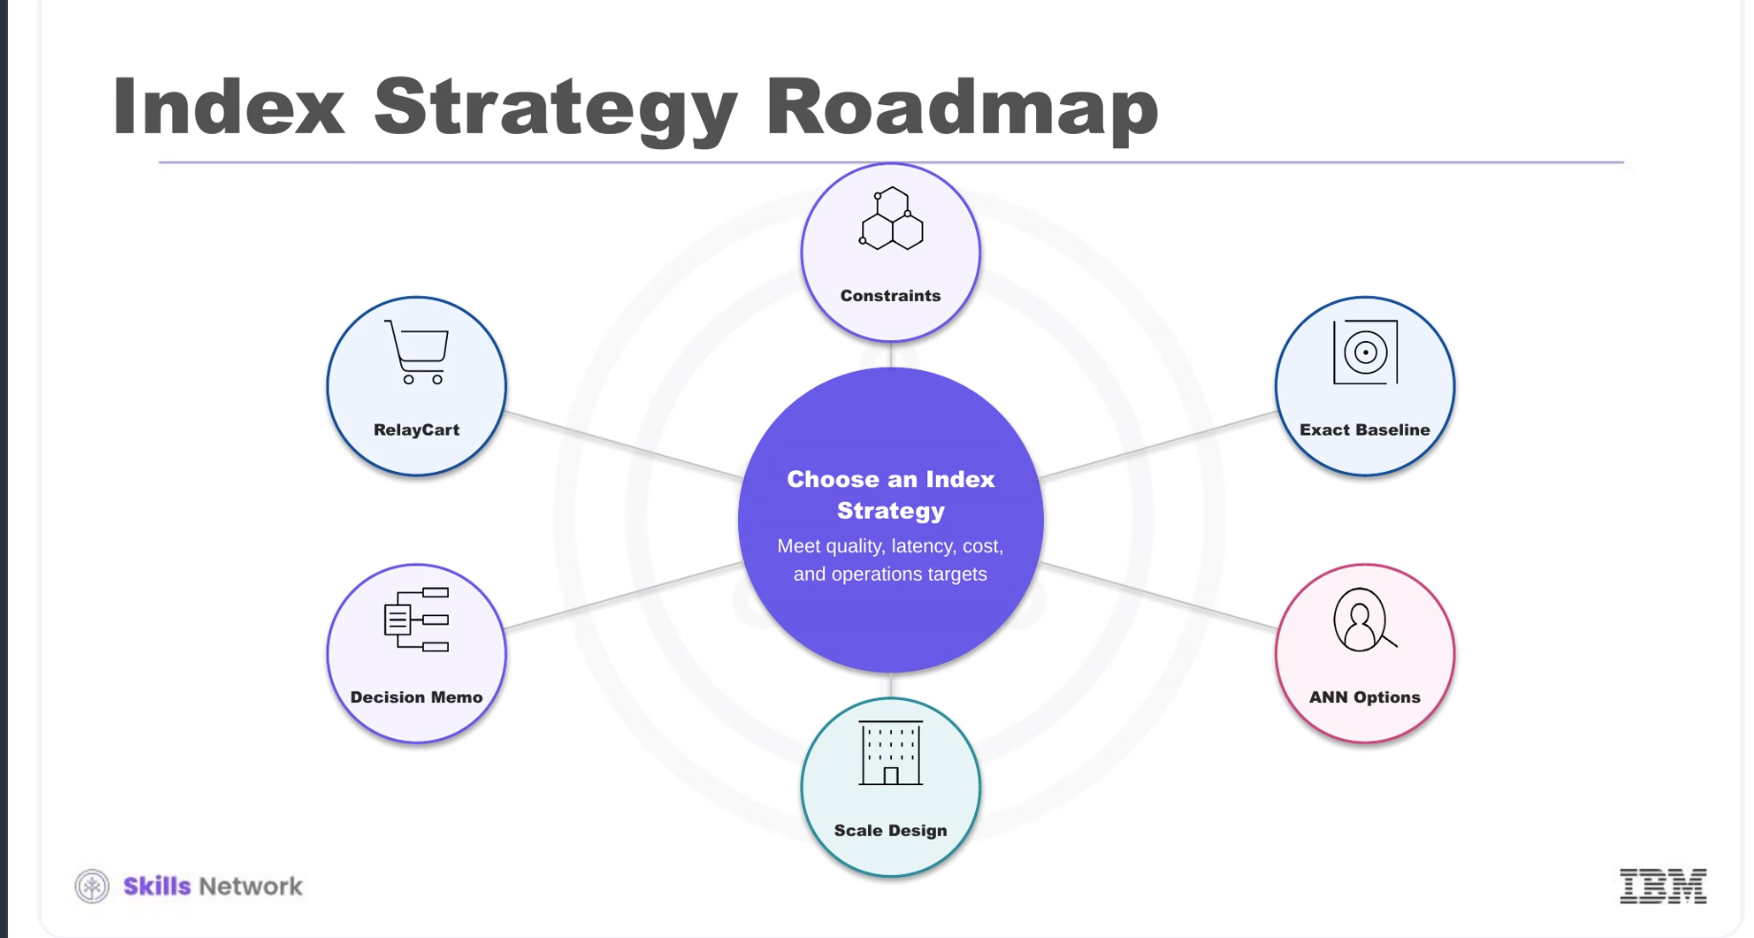
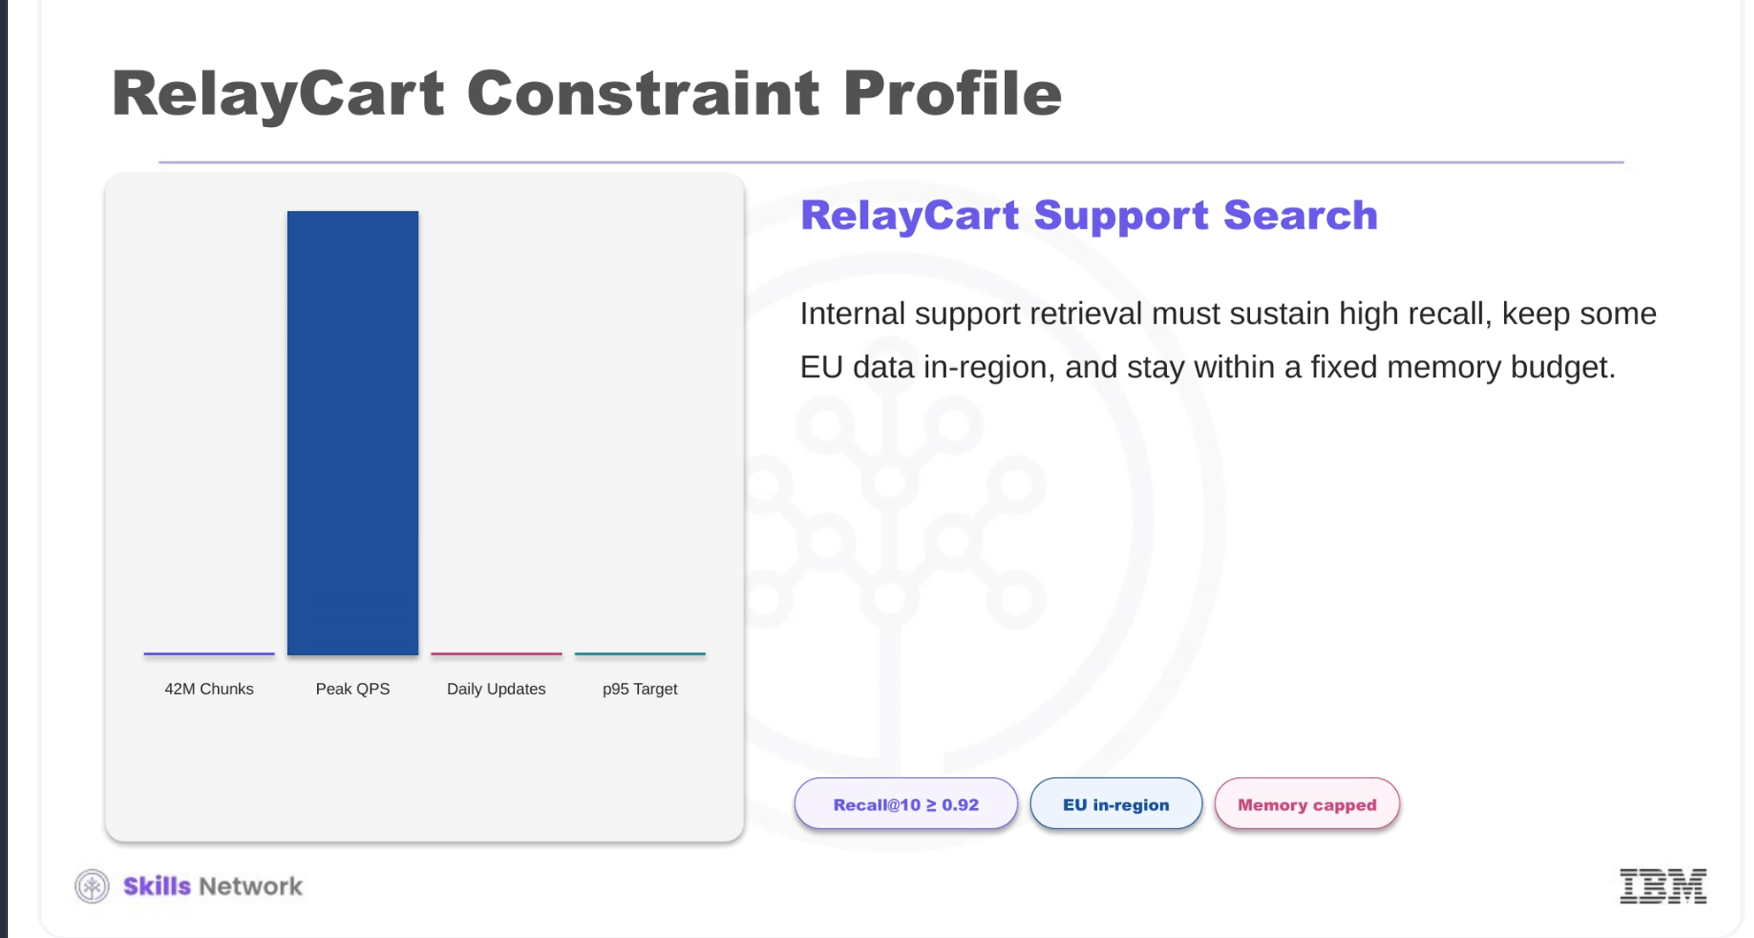
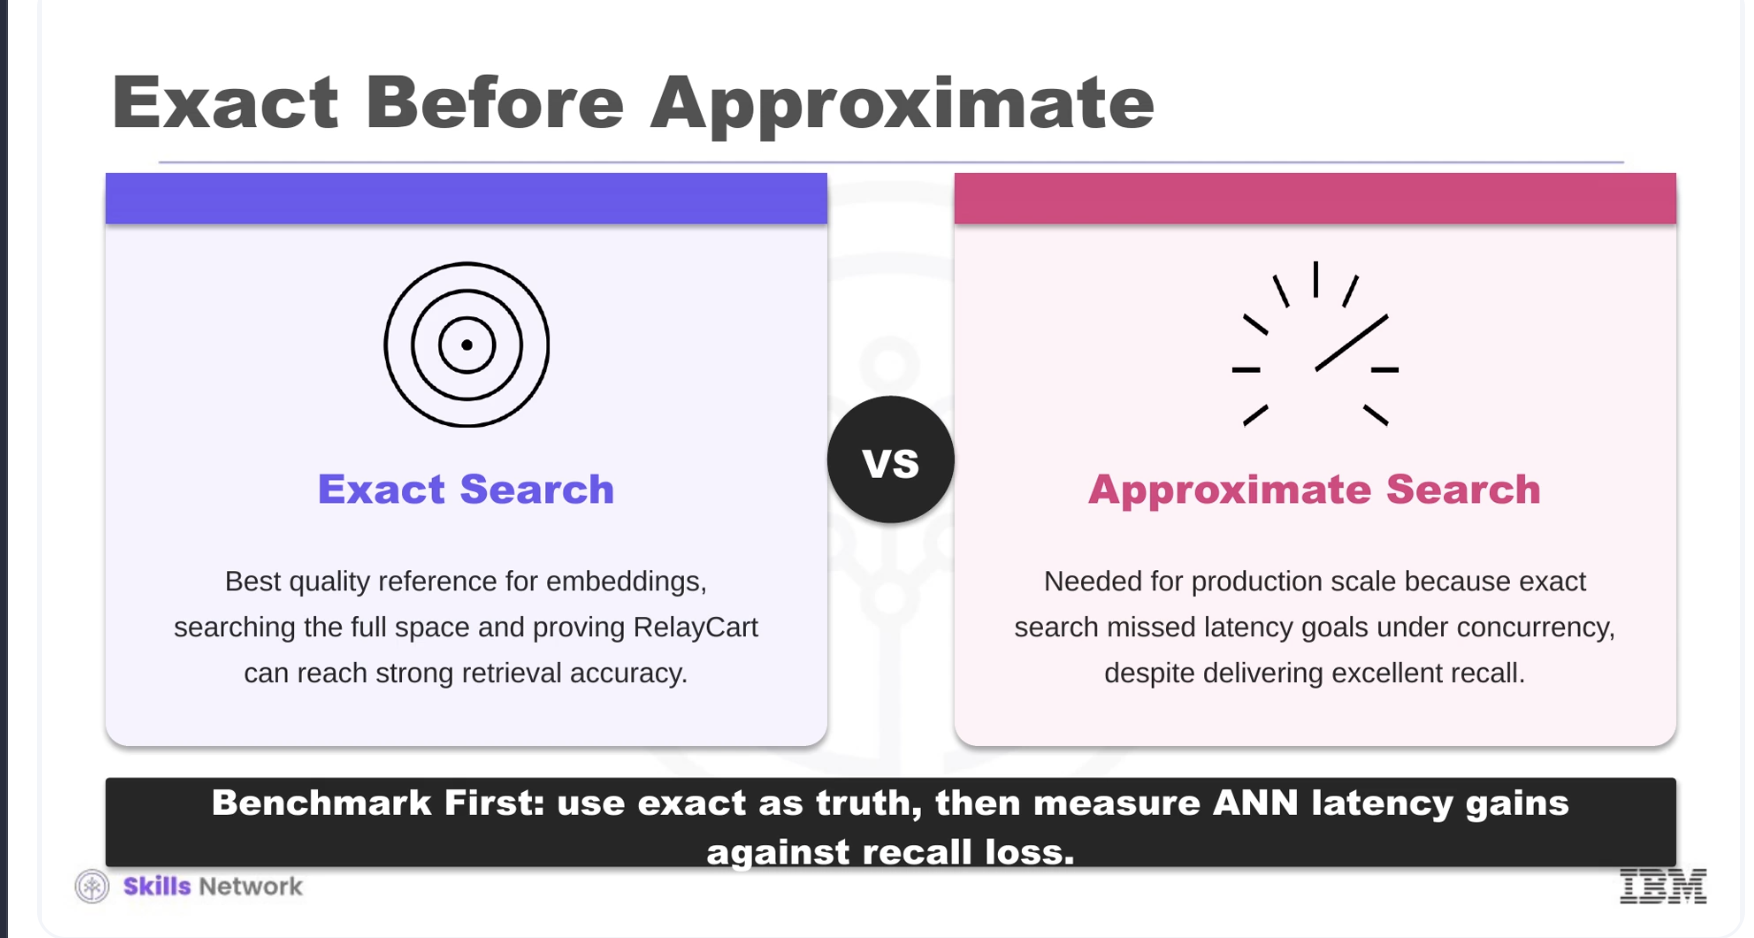
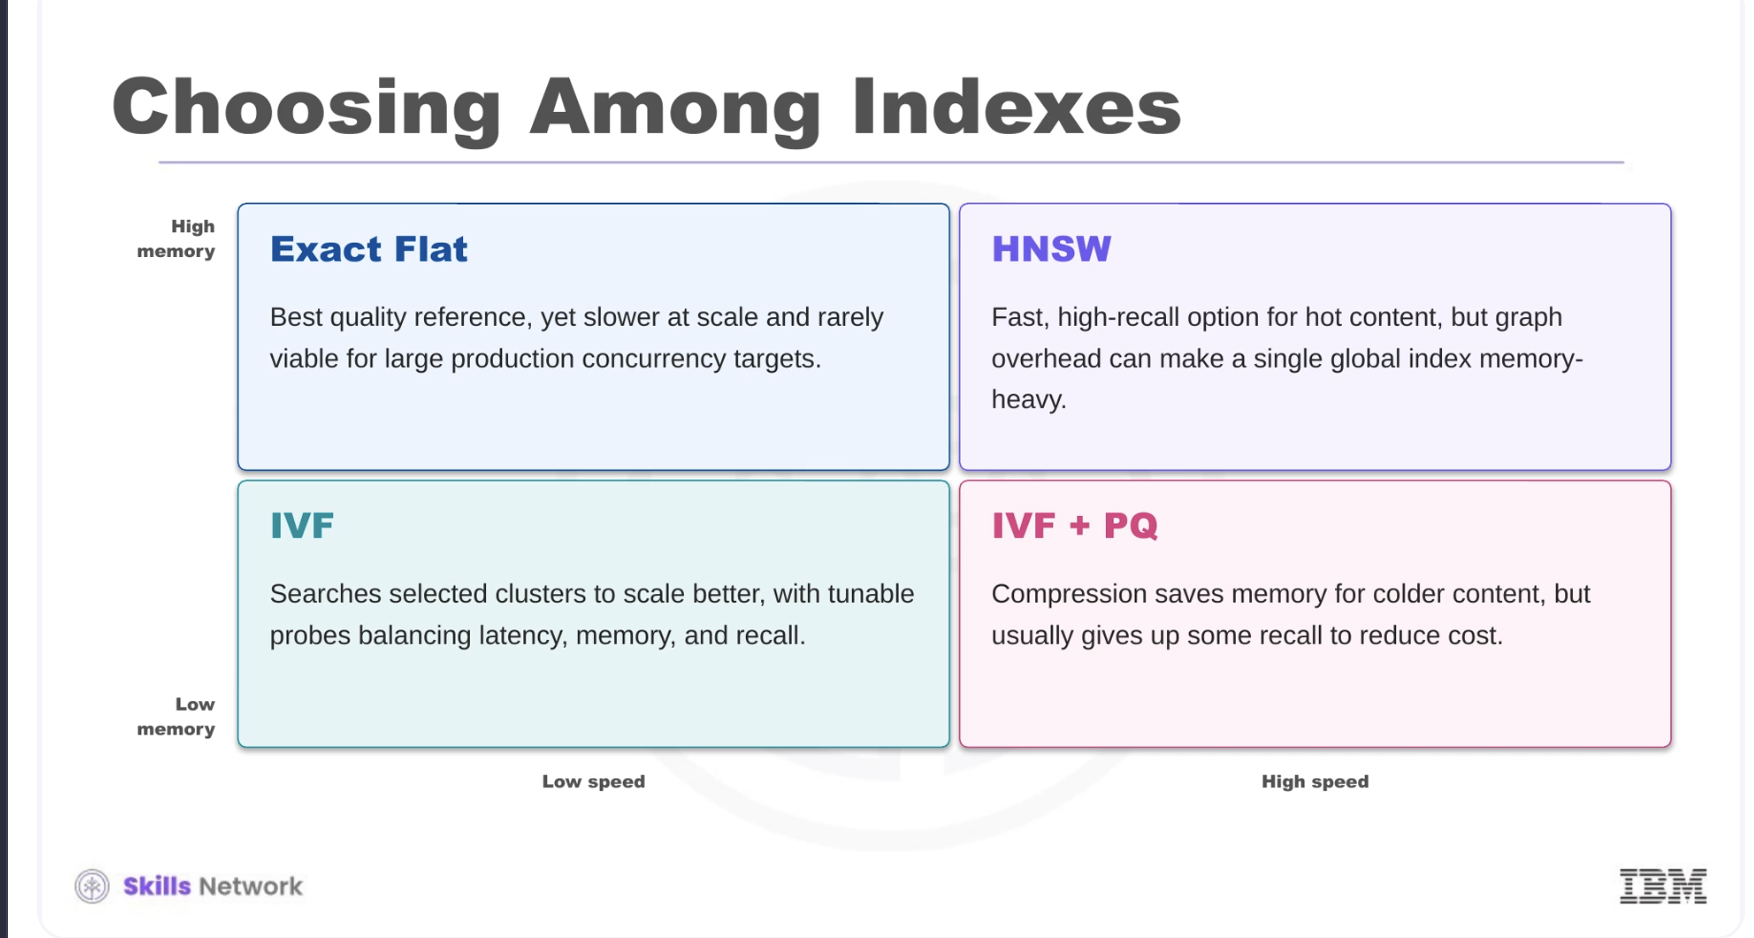
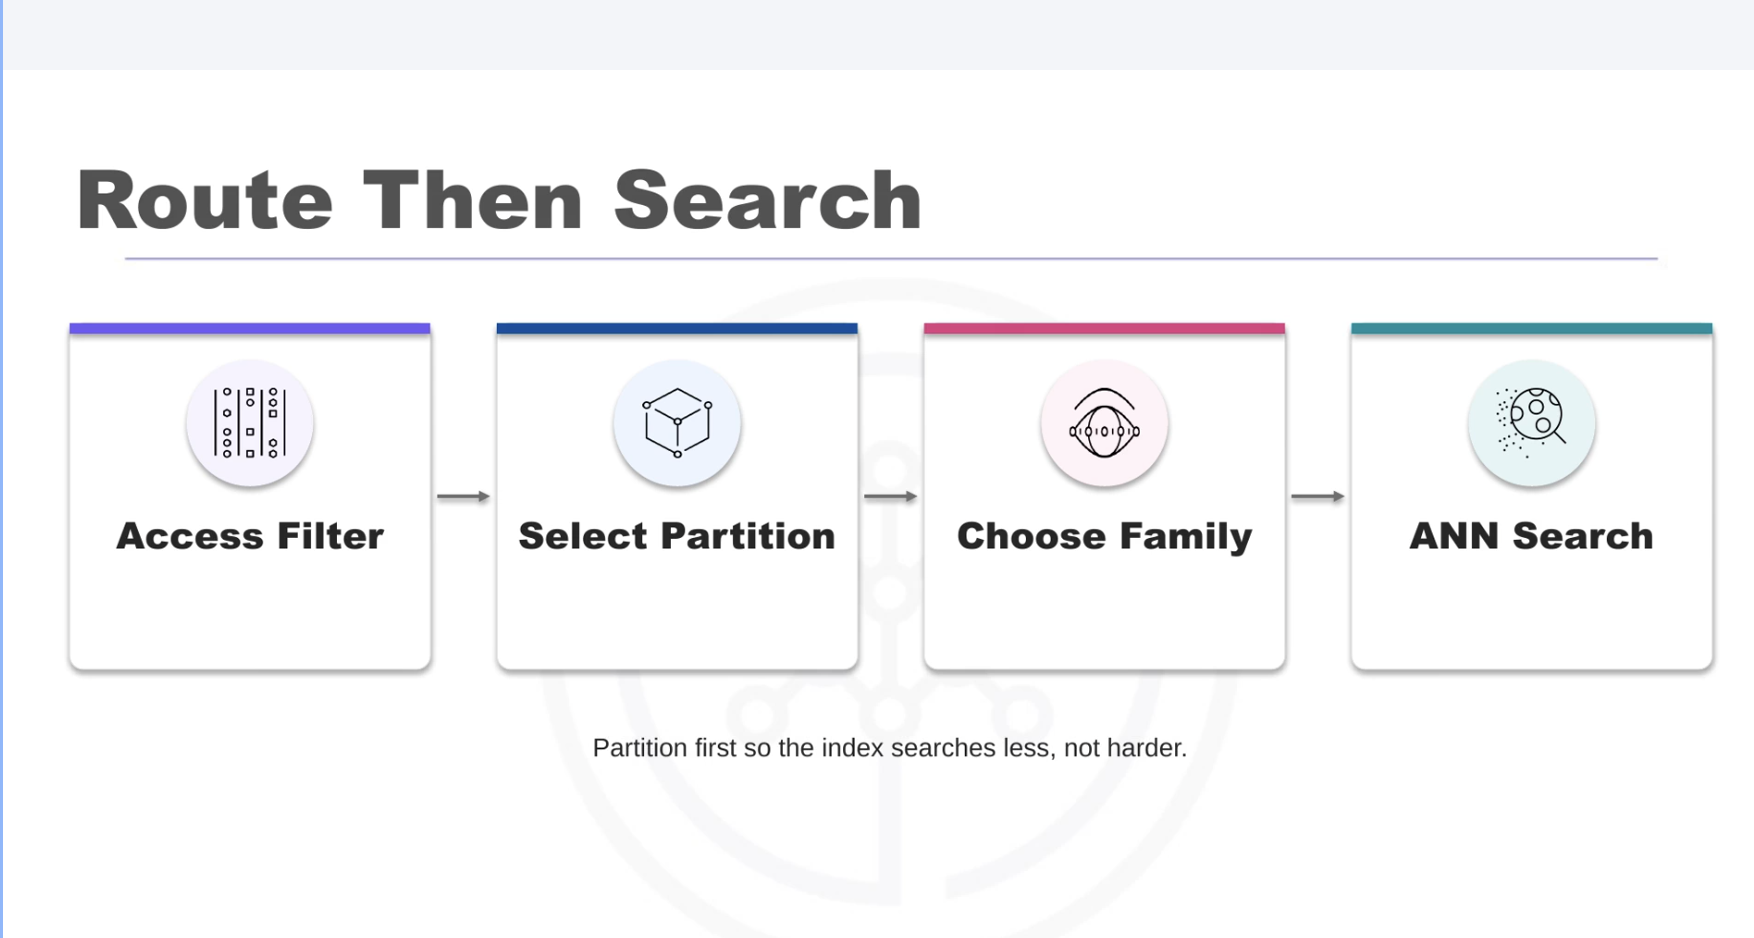
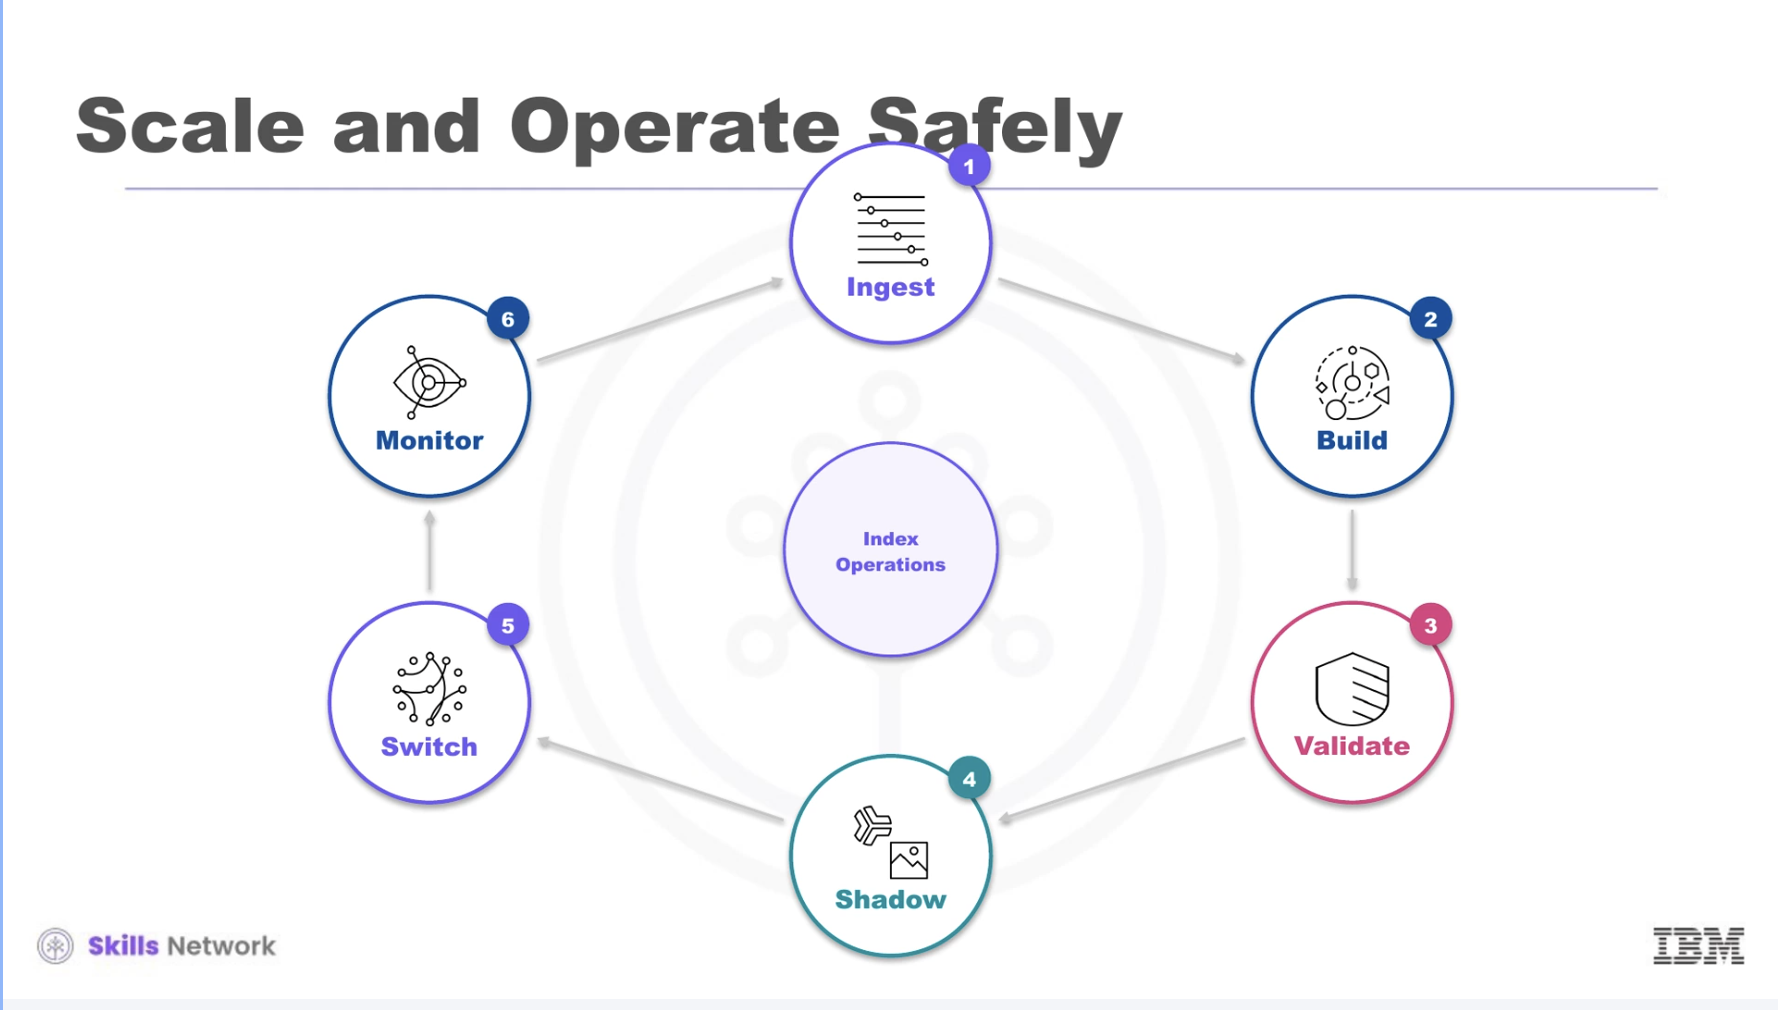 

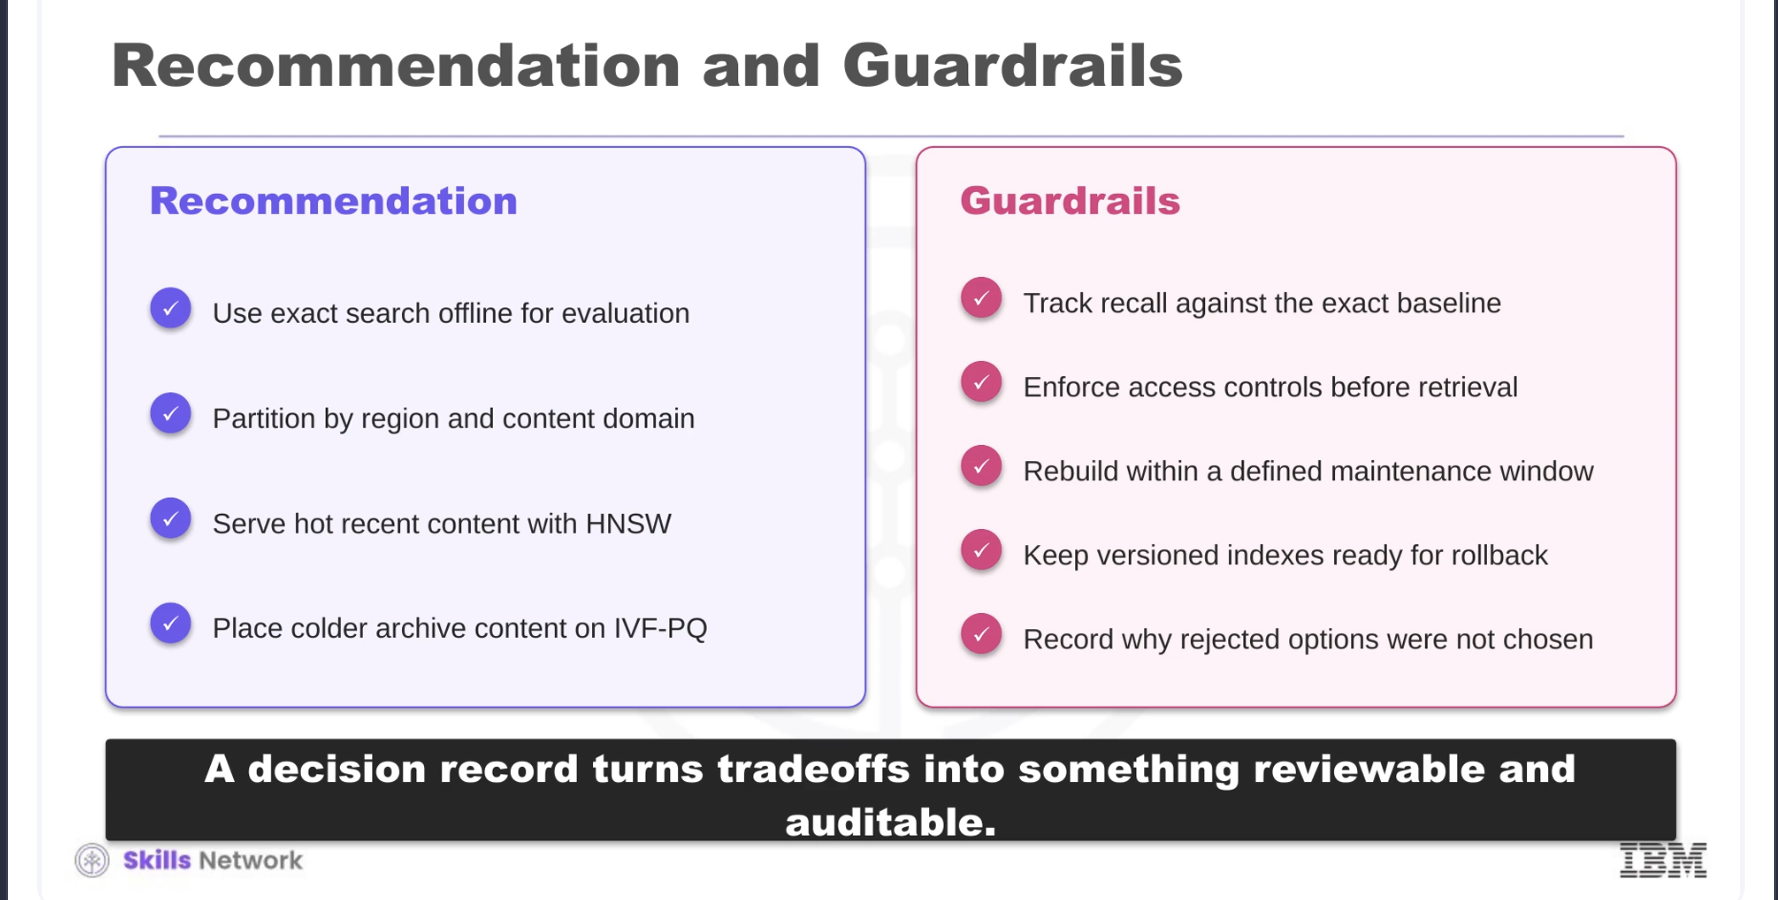


# Index Decision Records (IDR)

> 💡 **An index choice is a production engineering decision, not just a coding choice.**

---

## 1. The core idea

When I choose:

```
HNSW
vs
IVF
vs
Exact
```

I shouldn't just say:

> ❌ *"We chose HNSW because it's fast."*

I should be able to answer:

> ✅ **Why did we choose it, for what workload, under what constraints, based on what evidence, and when would we reconsider it?**

That's what an **Index Decision Record (IDR)** captures.

---

## 2. 🔴 What goes into the decision record

Remember these categories:

### Workload

```
Interactive search?
Batch retrieval?
How many queries?
What filters?
```

### Corpus

```
How many vectors?
What dimensionality?
How fast is it growing?
How often do documents update/delete?
```

### Quality

```
Recall@k target
NDCG / business relevance target
```

### Performance

```
P50
P95
P99
```

### Cost

```
RAM
Storage
Infrastructure limits
```

### Alternatives

```
What indexes did we consider?
Why were alternatives rejected?
```

### Risks

```
Recall degradation
Rebuild time
Filtering problems
Operational complexity
```

### Validation

```
What are we monitoring?
When do we benchmark again?
```

> 📌 These are the **minimum useful fields** described by the course.

| Field | Answers the question… |
|---|---|
| `Workload` | How is the index used (interactive/batch, volume, filters)? |
| `Corpus` | How big, how many dimensions, how fast growing/changing? |
| `Quality` | What recall / relevance must we hit? |
| `Performance` | What latency (P50/P95/P99) must we hit? |
| `Cost` | What RAM, storage, infra limits apply? |
| `Alternatives` | What else did we consider and why reject it? |
| `Risks` | What can go wrong with this choice? |
| `Validation` | What do we monitor and when do we re-benchmark? |

---

## 3. Why `P95` keeps appearing

I've already seen this in the BlueMesa case.

Suppose:

```
P95 latency = 120 ms
```

That means roughly: **95% of requests complete within 120 ms.**

I care about this because **an average latency can hide slow requests**.

> 📌 For production RAG, **tail latency matters**.

---

## 4. The really important concept: benchmark evidence

The course gives an example:

```
20 million vectors
768 dimensions

recall@10 >= 0.92
P95 < 120 ms
within memory budget
```

- Another index might use **less RAM** but **fail the recall requirement**.
- **Exact search** might have **excellent quality** but **violate latency/cost constraints**.

So the decision isn't:

> ❌ *"Which index is universally best?"*

It's:

> ✅ **"Which index satisfies the requirements of this particular workload?"**

That's an important engineering mindset.

---

## 5. ⚠️ Don't mix benchmark conditions

This is probably the **biggest practical lesson** in this section.

Suppose:

| | HNSW benchmark | IVF benchmark |
|---|---|---|
| Machine | Machine A | Machine B |
| Embedding model | Model X | Model Y |
| Filters | No filters | Heavy filters |

I **can't** fairly conclude:

> ❌ *"HNSW is faster than IVF."*

Because I changed **multiple variables**.

> 📌 The course explicitly warns against treating benchmarks from **different hardware, embedding models, or filter behavior** as interchangeable.

---

## 6. When do we revisit the decision?

This is the part to especially remember.

I choose an index today. Six months later, any of these can happen:

### Corpus growth

```
5M vectors
      ↓
20M vectors
```

Maybe the original index no longer works within my memory/latency budget.

### Model change

```
Embedding model changes
```

Maybe dimensionality/distribution changes.

### Query change

```
Query patterns change
```

Maybe users now use heavier filters.

### Stricter latency

```
Latency SLO becomes stricter
```

### Governance change

```
Governance requirements change
```

> 📌 These are **re-evaluation triggers**.

---

## 🧠 The mental model

Think of an Index Decision Record as:

```
             INDEX DECISION
                   │
       ┌───────────┼───────────┐
       ↓           ↓           ↓
   Workload    Constraints   Alternatives
       │           │           │
       └───────────┼───────────┘
                   ↓
               Benchmark
                   ↓
              Decision
                   ↓
                Risks
                   ↓
             Monitoring
                   ↓
        Re-evaluation triggers
```

So I'm basically **writing down the reasoning behind the architecture**.

---

## 7. For me specifically

Don't spend time learning how to write a fancy document. I just need to walk away knowing:

> 💡 **An index choice is a production engineering decision, not just a coding choice.**

And whenever I make one, record:

```
what I'm optimizing
        ↓
constraints
        ↓
benchmark evidence
        ↓
alternatives
        ↓
risks
        ↓
when to re-test
```

That's it. The rest of this section is essentially documentation structure around that idea.

# [INDEX_STRATEGY](Practical2/indexing.ipynb)